# 2.2 単振動の時間発展（1自由度系）

2.1 では単純な微分方程式を数値積分で解く，という計算をしました．<br>
実際に我々が直面する問題は微分方程式で表されることが多く，物体の運動方程式もその一つです．<br>
ここでは単振動の運動方程式を数値積分で解くことを考えます．<br>
ただし，先の計算も見据えて，ニュートンの運動方程式でなく解析力学で習ったハミルトンの運動方程式を使って時間発展させます．<br>
先の計算では $dy/dt$ 一つだけでしたが，この計算では $dq/dt, dp/dt$ と二つの微分方程式が現れるところが大きな違いになります．1自由度系の問題です．

---

ばね定数 $k$, 質量 $m$ のおもりの単振動を考える．

この時，ニュートンの運動方程式は
$$
    m \frac{dq}{dt} = - k q,
$$
と表される．

この方程式を正準運動方程式の形で書き直したい．
まずハミルトニアン $H$ として，
$$
    H = K + U = \frac{p^2}{2m} + \frac{kq^2}{2}
$$
この時，正準運動方程式は
$$
    \frac{dq}{dt} = \frac{\partial H}{\partial p} = \frac{p}{m},
$$
$$
    \frac{dp}{dt} = - \frac{\partial H}{\partial q} = - k q
$$
である．

これを Runge-Kutta 法で数値積分して時間発展を記述したい．
簡単のため， $m = k = 1$ としておく．

このとき，ハミルトニアンは
$$
    H = \frac{p^2}{2} + \frac{q^2}{2}
$$

初期条件として， $q=1$, $p=0$, すなわち, バネを 1　だけ伸ばした状態で静かに手を離す状況を考える．

また，時間発展の幅と終了時刻について，単振動の周期 $T$ は
$$
    T = 2 \pi \sqrt{\frac{m}{k}} = 2 \pi
$$
で表されることから， $t=0$ から $t = 3 \pi /2$，　すなわち 3/4 周期走らせることを考える． 刻み幅はとりあえず1000にする．

明らかにこのトラジェクトリは半径 1 の円周上を時計回りに (1, 0) から (0, 1)まで運動することがわかるが，　答えはその通りになるだろうか？

---

初期条件（再掲）：

・$t=0$ から $t = 3 \pi /2$まで

・1000分割

$t$に沿った$p, q$ の値を取得する．


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set()

In [2]:
# 初期条件他
q_0 = 1
p_0 = 0

# 3/2 pi まで走らせてみる場合
t_1000 = np.linspace(0, 3*np.pi/2, 1000)

In [3]:
def dqdt(pn):
    dqdt = pn
    return dqdt

def dpdt(qn):
    dpdt = - qn
    return dpdt

def runge_kutta_one(qn, pn, h):
    kq1 = dqdt(pn)
    kp1 = dpdt(qn)

    kq2 = dqdt(pn + h * kp1 /2)
    kp2 = dpdt(qn + h * kq1 /2)

    kq3 = dqdt(pn + h * kp2 /2)
    kp3 = dpdt(qn + h * kq2 /2)

    kq4 = dqdt(pn + h * kp3)
    kp4 = dpdt(qn + h * kq3)

    qn1 = qn + h * (kq1 + 2 * kq2 + 2 * kq3 + kq4) / 6
    pn1 = pn + h * (kp1 + 2 * kp2 + 2 * kp3 + kp4) / 6
    
    return qn1, pn1

In [4]:
### 追加! 関数の引数に関数を入れて, るんげくったの部分をもっと簡単に書けないか？？
def dqdt_test(qn, pn):
    dqdt = pn
    return dqdt

def dpdt_test(qn, pn):
    dpdt = - qn
    return dpdt

def arg_k23(yn, h, k):
    arg = yn + h * k / 2
    return arg

def arg_k4(yn, h, k):
    arg = yn + h * k
    return arg

def runge_kutta_process_yn(func, yn, qn, pn, h):
    """
    func: 関数．dqdt or dpdt. 引数は簡単のためにどちらも (qn, pn)にしてある
    """
    k1 = func(qn, pn)
    k2 = func(arg_k23(qn, h, k1), arg_k23(pn, h, k1))
    k3 = func(arg_k23(qn, h, k2), arg_k23(pn, h, k2))
    k4 = func(arg_k4(qn, h, k3), arg_k23(pn, h, k3))
    yn1 = yn + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return yn1

def runge_kutta_step(qn, pn, h):
    qn1 = runge_kutta_process_yn(dqdt_test, qn, qn, pn, h)
    pn1 = runge_kutta_process_yn(dpdt_test, pn, qn, pn, h)
    return qn1, pn1

In [5]:
def runge_kutta_roop(q0, p0, t_step):
    delta = t_step[1] - t_step[0]
    q_list = [q0]
    p_list = [p0]
    for i in range(len(t_step)-1):
        q_n = q_list[-1]
        p_n = p_list[-1]
        q_n1, p_n1 = runge_kutta_one(q_n, p_n, delta)
        #q_n1, p_n1 = runge_kutta_step(q_n, p_n, delta)
        q_list.append(q_n1)
        p_list.append(p_n1)
    return q_list, p_list

In [6]:
%%time
q_vib, p_vib = runge_kutta_roop(q_0, p_0, t_1000)

CPU times: user 8 ms, sys: 488 µs, total: 8.49 ms
Wall time: 8.05 ms


縦軸を$p$, 横軸を$q$に取った$q-p$平面上にプロットしてください．

この時，トラジェクトリは3/4円を描くでしょうか？

Text(0, 0.5, '$p$')

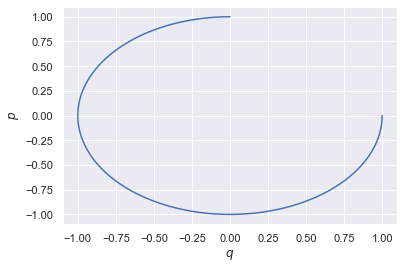

In [7]:
plt.plot(q_vib, p_vib)
plt.xlabel('$q$')
plt.ylabel('$p$')

---

---

### <<<以下余裕と興味がある人向けの長いAppendix>>>



---

次に，刻み幅をもう少し大きく，　もっと長時間トラジェクトリを走らせるとどうなるか？

0 から $100000 \times 2 \pi$ まで, 0.1 刻みで時間発展させてみる

xの範囲を[0.975, 1.025]，yの範囲を[-0.25, 0.25]などして，$(q, p) = (1, 0)$ 付近を拡大してみてみると...?

In [8]:
%%time
def check_diff(total_t, step):
    t_list = np.arange(0, total_t, step)
    q_vib, p_vib = runge_kutta_roop(q_0, p_0, t_list)
    return q_vib, p_vib

def plot_diff(q_list, p_list, q_lim, p_lim):
    plt.plot(q_list, p_list)
    plt.xlabel('$q$')
    plt.ylabel('$p$')
    plt.xlim(q_lim)
    plt.ylim(p_lim)


CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 8.11 µs


CPU times: user 4.77 s, sys: 28.8 ms, total: 4.8 s
Wall time: 4.8 s


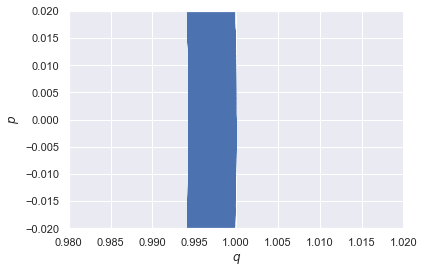

In [9]:
%%time
q_vib_01, p_vib_01 = check_diff(10000*2*np.pi, 0.1)
plot_diff(q_vib_01, p_vib_01, [0.98, 1.02], [-0.02, 0.02])

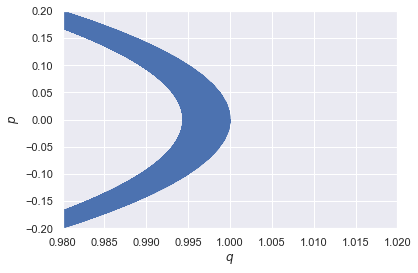

In [19]:
plot_diff(q_vib_01, p_vib_01, [0.98, 1.02], [-0.2, 0.2])

Runge-Kutta法はシンプレクティック数値積分ではないのでエネルギーが保存しない（=1本の線にならない）

では刻み幅をもっと小さく (0.001) 取ってみると.
..?

CPU times: user 7min 42s, sys: 3.02 s, total: 7min 45s
Wall time: 7min 45s


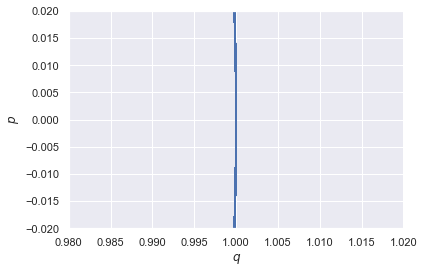

In [10]:
%%time
q_vib_0001, p_vib_0001 = check_diff(10000*2*np.pi, 0.001)
plot_diff(q_vib_0001, p_vib_0001, [0.98, 1.02], [-0.02, 0.02])

計算回数が100倍になるので計算時間は延びますが，刻み幅を十分小さく取ればエネルギーが保存することがわかります．

### 参考：シンプレクティック数値積分

力学系の時間発展を記述する上では，　全エネルギーが保存するような数値積分，　シンプレクティック数値積分法が用いられます．

ここでは2次のシンプレクティック数値積分を実行してみる．

細かい式はwikipedia参照https://ja.wikipedia.org/wiki/%E3%82%B7%E3%83%B3%E3%83%97%E3%83%AC%E3%82%AF%E3%83%86%E3%82%A3%E3%83%83%E3%82%AF%E6%95%B0%E5%80%A4%E7%A9%8D%E5%88%86%E6%B3%95

In [11]:
def dVdq(q):
    # V = kq^2 / 2, k = 1
    dVdq = q
    return dVdq

def symplectic_2order_one(qn, pn, h):
    q_nhalf = qn + h * pn / 2
    dVdq_temp = dVdq(q_nhalf) 
    pn1 = pn - h * dVdq_temp
    qn1 = q_nhalf + h * pn1 / 2
    return qn1, pn1

def symplectic_2order_roop(q0, p0, t_step):
    delta = t_step[1] - t_step[0]
    q_list = [q0]
    p_list = [p0]
    for i in range(len(t_step)-1):
        q_n = q_list[-1]
        p_n = p_list[-1]
        q_n1, p_n1 = symplectic_2order_one(q_n, p_n, delta)
        q_list.append(q_n1)
        p_list.append(p_n1)
    return q_list, p_list

CPU times: user 2.75 s, sys: 143 ms, total: 2.89 s
Wall time: 2.89 s


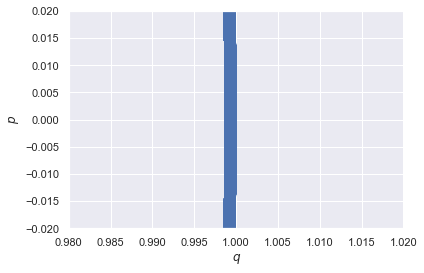

In [12]:
%%time
t_list = np.arange(0, 10000*2*np.pi, 0.1)
q_vib_sym, p_vib_sym = symplectic_2order_roop(q_0, p_0, t_list)
plot_diff(q_vib_sym, p_vib_sym, [0.98, 1.02], [-0.02, 0.02])

Runge-Kutta法よりは少し遅いですが（1.5倍の時間）， エネルギー保存の精度は刻み幅を100倍にした時と同程度ですね!!

#### 1次のシンプレクティック数値積分も試してみる

もっと簡単な 1次の方法（改良オイラー法）も試してみます．

In [13]:
def symplectic_1order_one(qn, pn, h):
    dVdq_temp = dVdq(qn) 
    pn1 = pn - h * dVdq_temp
    qn1 = qn + h * pn1
    return qn1, pn1

def symplectic_1order_roop(q0, p0, t_step):
    delta = t_step[1] - t_step[0]
    q_list = [q0]
    p_list = [p0]
    for i in range(len(t_step)-1):
        q_n = q_list[-1]
        p_n = p_list[-1]
        q_n1, p_n1 = symplectic_1order_one(q_n, p_n, delta)
        q_list.append(q_n1)
        p_list.append(p_n1)
    return q_list, p_list

CPU times: user 31.9 ms, sys: 3.53 ms, total: 35.4 ms
Wall time: 32.7 ms


Text(0, 0.5, '$p$')

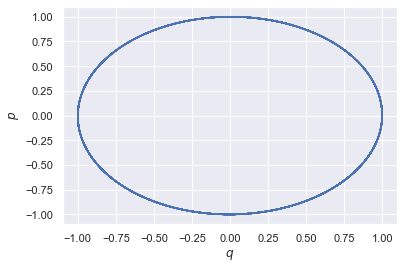

In [14]:
%%time
t_list = np.arange(0, 10*2*np.pi, 0.01)
q_vib, p_vib = symplectic_1order_roop(q_0, p_0, t_list)
plt.plot(q_vib, p_vib)
plt.xlabel('$q$')
plt.ylabel('$p$')

Runge-Kutta法より速いのに， エネルギーがよく保存している！！！！

せっかくなので普通のEuler法も試してみる

In [15]:
def euler_one(qn, pn, h):
    dVdq_temp = dVdq(qn) 
    pn1 = pn - h * dVdq_temp
    qn1 = qn + h * pn
    return qn1, pn1

def euler_roop(q0, p0, t_step):
    delta = t_step[1] - t_step[0]
    q_list = [q0]
    p_list = [p0]
    for i in range(len(t_step)-1):
        q_n = q_list[-1]
        p_n = p_list[-1]
        q_n1, p_n1 = euler_one(q_n, p_n, delta)
        q_list.append(q_n1)
        p_list.append(p_n1)
    return q_list, p_list

CPU times: user 31.9 ms, sys: 2.56 ms, total: 34.4 ms
Wall time: 32.3 ms


Text(0, 0.5, '$p$')

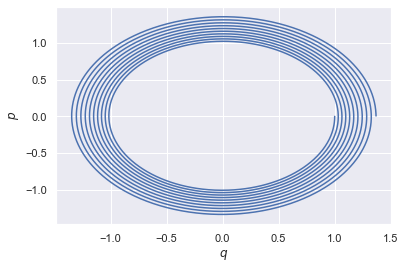

In [16]:
%%time
t_list = np.arange(0, 10*2*np.pi, 0.01)
q_vib, p_vib = euler_roop(q_0, p_0, t_list)
plt.plot(q_vib, p_vib)
plt.xlabel('$q$')
plt.ylabel('$p$')

ほんの少し結果を変えただけなのにこんなに変わるんですね